<a href="https://colab.research.google.com/github/SOHAM7110/CNN-model-For-Sclerosis-Classification/blob/main/car_price_eda_using_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***$$Car-Price-EDA-Using-python$$***

# 1. Read your data set using pandas
# 2. Cleaning the data set
# 3. Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ***Read your data set using pandas***

In [ ]:
df = pd.read_csv('/content/car-data.csv')

## **df.head()** *is used to get the first five rolls of the DataFrame*

In [ ]:
df.head()

,symboling,normalized-losses,carName,fuel-type,num-of-doors,num-of-cylinders,engine-size,horsepower,highway-mpg,price
0,3,NaN,alfa-romero,gas,two,four,130,111,27,13495.0
1,3,NaN,alfa-romero,gas,two,four,130,111,27,16500.0
2,1,NaN,alfa-romero,diesel,two,six,152,154,26,16500.0
3,2,164.0,audi,gas,four,four,109,102,30,13950.0
4,2,164.0,audi,gas,four,five,136,115,22,17450.0


## **df.tail()** *is used to get the last five rows in the DataFrame*

In [ ]:
df.tail()

,symboling,normalized-losses,carName,fuel-type,num-of-doors,num-of-cylinders,engine-size,horsepower,highway-mpg,price
45,0,NaN,isuzu,gas,four,four,90,70,43,NaN
46,2,NaN,isuzu,diesel,two,four,119,90,29,11048.0
47,0,145.0,jaguar,gas,four,six,258,176,19,32250.0
48,0,NaN,jaguar,gas,four,six,258,176,19,35550.0
49,0,NaN,jaguar,diesel,two,twelve,326,262,17,36000.0


## **isnull.sum()** *function sums all the null values for each columns*

In [ ]:
df.isnull().sum()

symboling             0
normalized-losses    16
carName               0
fuel-type             0
num-of-doors          1
num-of-cylinders      0
engine-size           0
horsepower            0
highway-mpg           0
price                 3
dtype: int64

## **df.info()** *helps us get the data types of the columns in the DataFrame and also the number of non-null values and the total entry i.e the row and columns*

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          50 non-null     int64  
 1   normalized-losses  34 non-null     float64
 2   carName            50 non-null     object 
 3   fuel-type          50 non-null     object 
 4   num-of-doors       49 non-null     object 
 5   num-of-cylinders   50 non-null     object 
 6   engine-size        50 non-null     int64  
 7   horsepower         50 non-null     int64  
 8   highway-mpg        50 non-null     int64  
 9   price              47 non-null     float64
dtypes: float64(2), int64(4), object(4)
memory usage: 4.0+ KB
None


## *we can see that we have some null values, so let us now visualize the null values with a heatmap using seaborn*

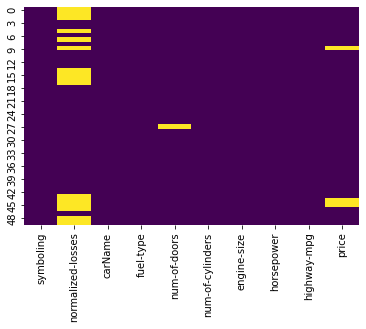

In [ ]:
sns.heatmap(df.isnull(),cbar=False, cmap='viridis')

## *Plotting the null values let you know if you are to drop the column or not since most of the null values came from the normalized losses normalized_losses while other columns have fewer missing values. We can’t drop the normalized_losses column as it may be important for our prediction.*

### *let get a view of the data again so we can see the variables we can use the .columns method or .head() function*

In [ ]:
print(list(df.columns))
df.head()

['symboling', 'normalized-losses', 'carName', 'fuel-type', 'num-of-doors', 'num-of-cylinders', 'engine-size', 'horsepower', 'highway-mpg', 'price']


,symboling,normalized-losses,carName,fuel-type,num-of-doors,num-of-cylinders,engine-size,horsepower,highway-mpg,price
0,3,NaN,alfa-romero,gas,two,four,130,111,27,13495.0
1,3,NaN,alfa-romero,gas,two,four,130,111,27,16500.0
2,1,NaN,alfa-romero,diesel,two,six,152,154,26,16500.0
3,2,164.0,audi,gas,four,four,109,102,30,13950.0
4,2,164.0,audi,gas,four,five,136,115,22,17450.0


#### *As shown from the head() function we can see that there are some missing values in normalized-losses, num-of cylinders, and price*

# **$$Cleaning-the-Data-Set$$**

### We can use the fillna function to replace the Nan rows with a value in this case we are going to use the mean with columns that have a datatype of floats or integers

In [ ]:
df['normalized-losses'] = df['normalized-losses'].fillna(df['normalized-losses'].mean())

In [ ]:
df['normalized-losses'] # printing the values to see that the Nan rows have been replaced by the mean

0     129.088235
1     129.088235
2     129.088235
3     164.000000
4     164.000000
5     129.088235
6     158.000000
7     129.088235
8     158.000000
9     129.088235
10    192.000000
11    192.000000
12    188.000000
13    188.000000
14    129.088235
15    129.088235
16    129.088235
17    129.088235
18    121.000000
19     98.000000
20     81.000000
21    118.000000
22    118.000000
23    118.000000
24    148.000000
25    148.000000
26    148.000000
27    148.000000
28    110.000000
29    145.000000
30    137.000000
31    137.000000
32    101.000000
33    101.000000
34    101.000000
35    110.000000
36     78.000000
37    106.000000
38    106.000000
39     85.000000
40     85.000000
41     85.000000
42    107.000000
43    129.088235
44    129.088235
45    129.088235
46    129.088235
47    145.000000
48    129.088235
49    129.088235
Name: normalized-losses, dtype: float64

In [ ]:
df['price'].fillna(df['price'].mean(), inplace=True)
''' printing the values to see that the Nan rows have been replaced by the mean
    we use the inplace=True to modfiy the value of df['price'] on that line of code
'''

" printing the values to see that the Nan rows have been replaced by the mean \n    we use the inplace=True to modfiy the value of df['price'] on that line of code\n"

In [ ]:
df['price'] # printing the values to see that the Nan rows have been replaced by the mean

0     13495.000000
1     16500.000000
2     16500.000000
3     13950.000000
4     17450.000000
5     15250.000000
6     17710.000000
7     18920.000000
8     23875.000000
9     14458.170213
10    16430.000000
11    16925.000000
12    20970.000000
13    21105.000000
14    24565.000000
15    30760.000000
16    41315.000000
17    36880.000000
18     5151.000000
19     6295.000000
20     6575.000000
21     5572.000000
22     6377.000000
23     7957.000000
24     6229.000000
25     6692.000000
26     7609.000000
27     8558.000000
28     8921.000000
29    12964.000000
30     6479.000000
31     6855.000000
32     5399.000000
33     6529.000000
34     7129.000000
35     7295.000000
36     7295.000000
37     7895.000000
38     9095.000000
39     8845.000000
40    10295.000000
41    12945.000000
42    10345.000000
43     6785.000000
44    14458.170213
45    14458.170213
46    11048.000000
47    32250.000000
48    35550.000000
49    36000.000000
Name: price, dtype: float64

#### *We can also use the bfill() function to replace  backward fill the missing values in the dataset. which is using the data after it to replace the missing value before it if there is a missing value after the Nan and nothing after it will not be backfilled and it will remain Nan*

In [ ]:
df['num-of-doors'] = df['num-of-doors'].bfill()

In [ ]:
print(df['num-of-doors'])

0      two
1      two
2      two
3     four
4     four
5      two
6     four
7     four
8     four
9      two
10     two
11    four
12     two
13    four
14    four
15    four
16     two
17    four
18     two
19     two
20    four
21     two
22     two
23     two
24    four
25    four
26    four
27    four
28    four
29     two
30     two
31     two
32     two
33     two
34     two
35    four
36    four
37     two
38     two
39    four
40    four
41    four
42     two
43    four
44     two
45    four
46     two
47    four
48    four
49     two
Name: num-of-doors, dtype: object


## *If we check the sum of null values now we should not see any*

In [ ]:
df.isnull().sum()

symboling            0
normalized-losses    0
carName              0
fuel-type            0
num-of-doors         0
num-of-cylinders     0
engine-size          0
horsepower           0
highway-mpg          0
price                0
dtype: int64

#### *Now we have no Null values in our data set it is now time to analyze the data let use the describe function to get an overview of our data, asking questions related to independent variables and the target variable. For example – how fuel_type will affect the price of the car?*

## **The descibe function shows description of each columns or variables:**
* ***count:*** which is the number of observation of a variable
* ***mean:*** which is the average of each variable
* ***std:*** which is the standard deviation of each variable
* ***min:*** which is the minimum value of each variable
* ***25%:*** which is the 25% percentile of each variable
* ***50%:*** which is the 50% percentile of each variable
* ***75%:*** which is the 75% percentile of each variable
* ***max:*** which is the maximum value of each variable    


In [ ]:
df.describe()

,symboling,normalized-losses,engine-size,horsepower,highway-mpg,price
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.840000,129.088235,127.400000,105.280000,31.160000,14458.170213
std,0.933722,27.786627,51.739536,42.378296,8.394264,9400.330965
min,-1.000000,78.000000,61.000000,48.000000,17.000000,5151.000000
25%,0.000000,110.000000,92.000000,76.000000,25.000000,7170.500000
50%,1.000000,129.088235,110.000000,100.500000,30.000000,11996.500000
75%,1.000000,145.000000,136.000000,119.500000,37.000000,17318.750000
max,3.000000,192.000000,326.000000,262.000000,54.000000,41315.000000


## **Coefficient of Variation**
We can find the coeffiecient of varition by dividing the standard deviation by the mean, the function to find the standard deviation is ***np.std()*** while mean is ***np.mean(),***
***Note:*** we can only use integers or float values to find coefficient of variation

In [ ]:
sy = np.std(df['symboling']) / np.mean(df['symboling'])
print("symbolying coeffcient of variation: ", sy)

nl = np.std(df['normalized-losses']) / np.mean(df['normalized-losses'])
print("normalized-losses coeffcient of variation: ", nl)

es = np.std(df['engine-size']) / np.mean(df['engine-size'])
print("engine-size coeffcient of variation: ", es)

hp = np.std(df['horsepower']) / np.mean(df['horsepower'])
print("horsepower coeffcient of variation: ", hp)

hm = np.std(df['highway-mpg']) / np.mean(df['highway-mpg'])
print("highway-mpg coeffcient of variation: ", hm)

pr = np.std(df['price']) / np.mean(df['price'])
print("price coeffcient of variation: ", pr)

symbolying coeffcient of variation:  1.1004019055515561
normalized-losses coeffcient of variation:  0.2130895758386973
engine-size coeffcient of variation:  0.4020371077404247
horsepower coeffcient of variation:  0.3984837860567393
highway-mpg coeffcient of variation:  0.2666847789784516
price coeffcient of variation:  0.6436397374246394


**We can find the correlation between the variables using the .corr() function, Note: correlation ranges from -1 to 1**
* ***corr = 1:*** perfect positive relationship
* ***corr = 0:***  : no relationship
* ***corr = -1:***  : perfect negative relationship

In [ ]:
df.corr()

,symboling,normalized-losses,engine-size,horsepower,highway-mpg,price
symboling,1.000000,0.244261,-0.253801,-0.194831,0.146541,-0.235631
normalized-losses,0.244261,1.000000,0.216555,0.242113,-0.283776,0.329994
engine-size,-0.253801,0.216555,1.000000,0.937205,-0.749112,0.897723
horsepower,-0.194831,0.242113,0.937205,1.000000,-0.828595,0.883818
highway-mpg,0.146541,-0.283776,-0.749112,-0.828595,1.000000,-0.730348
price,-0.235631,0.329994,0.897723,0.883818,-0.730348,1.000000


#### *We can see from the table the correlation between the variables*

## **To visualize the corr we can use a heatmap**

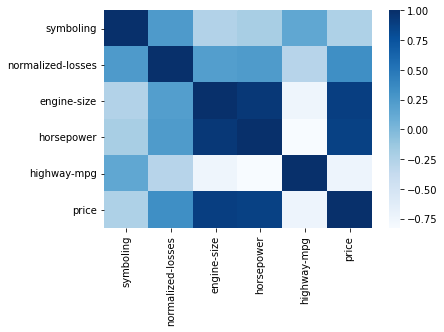

In [ ]:
sns.heatmap(df.corr(), cmap='Blues')

# **$$Analysis$$**
### *In this section we are going to be plotting our variables to see the relationship, we will be making use of matplotlib and seaborn to plot our data*

## ***How does the horsepower affect the price?***

# ***$$Graph$$***

### ***Making use of matplolib***

Text(0, 0.5, 'Price')

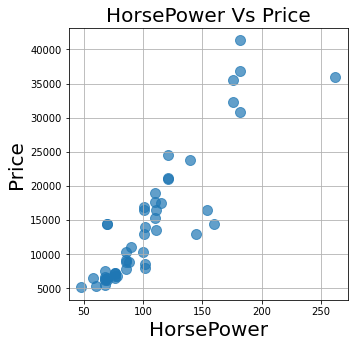

In [ ]:
plt.figure(figsize=[5,5])
plt.scatter(x=df['horsepower'], y=df['price'], s=100, alpha=0.7)
plt.grid()
plt.title("HorsePower Vs Price", fontsize=20)
plt.xlabel("HorsePower", fontsize=20)
plt.ylabel("Price", fontsize=20)

### ***Making use of seaborn***

Text(0, 0.5, 'Price')

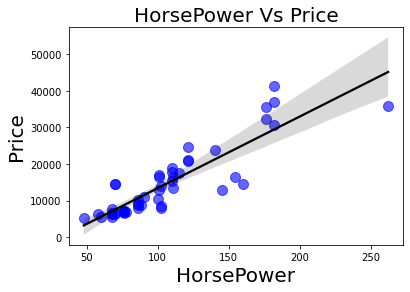

In [ ]:
sns.regplot(x=df['horsepower'], y=df['price'], scatter_kws={"color":"blue", "s":100, "alpha":0.6},
            line_kws={"color":"black"})
plt.title("HorsePower Vs Price", fontsize=20)
plt.xlabel("HorsePower", fontsize=20)
plt.ylabel("Price", fontsize=20)

 *We can see that most of the Horsepower that lie between 50 - 100 have a price of 5000 - 10000, ***Horsepower increases Price increases***, we have some outliers between 200 - 300 horsepower, let use a Histogram to see the how many cars have a particular horsepower value*

# ***$$Histogram$$***

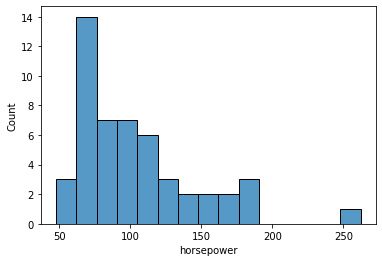

In [ ]:
sns.histplot(df.horsepower, bins=15)

 ### *Bins here mean are equally-spaced intervals that are used to sort data on graphs*

## **What then is the relationship between enginesize and price since the heatmap it has a good correlation of 0.89??**

# ***$$Graph$$***

Text(0, 0.5, 'Price')

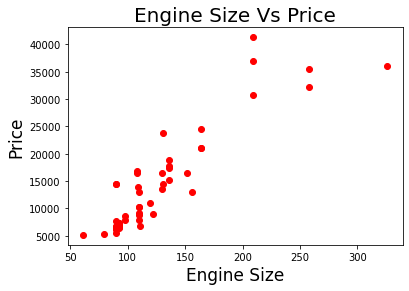

In [ ]:
plt.scatter(x = df['engine-size'], y=df['price'], c='r')
plt.title("Engine Size Vs Price", fontsize=20)
plt.xlabel("Engine Size", fontsize=17)
plt.ylabel("Price", fontsize=17)

### **We can use the sns.regplot() to draw a line through**

Text(0, 0.5, 'Price')

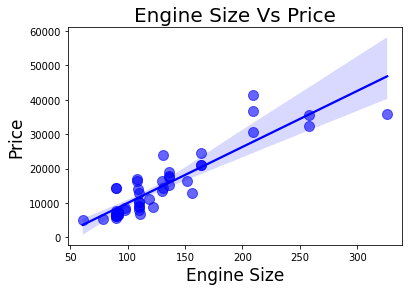

In [ ]:
sns.regplot(x=df['engine-size'], y=df['price'], scatter_kws={"color":"blue", "s":100, "alpha":0.6},
            line_kws={"color":"blue"})
plt.title("Engine Size Vs Price", fontsize=20)
plt.xlabel("Engine Size", fontsize=17)
plt.ylabel("Price", fontsize=17)

#### we can see that most of the cars have an engine size between 80 - 120 and have a price between 5000 - 20000 and as ***Engine Size increases Price increases*** and we have some outliers between engine size of 250 - 300

# ***$$Histogram$$***

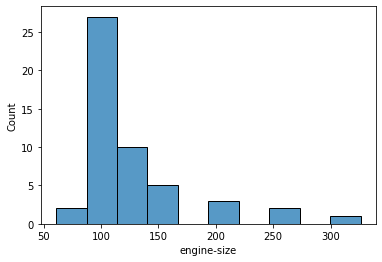

In [ ]:
sns.histplot(df['engine-size'], bins=10)

### *we can see most of the cars engine size are in the 90 - 120 range*

# **What then is the relationship between Highway mpg and price ??**

# ***$$Graph$$***

Text(0, 0.5, 'Price')

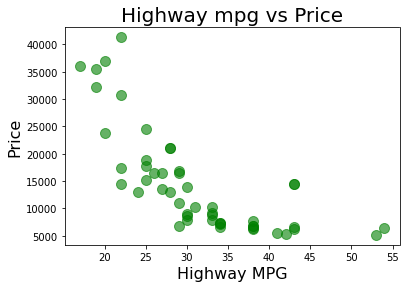

In [ ]:
plt.scatter(x=df['highway-mpg'], y=df['price'], color='green', s=100, alpha=0.6)
plt.title("Highway mpg vs Price", fontsize=20)
plt.xlabel("Highway MPG", fontsize=16)
plt.ylabel("Price", fontsize=16)

### **using sns.regplot()**

Text(0, 0.5, 'Price')

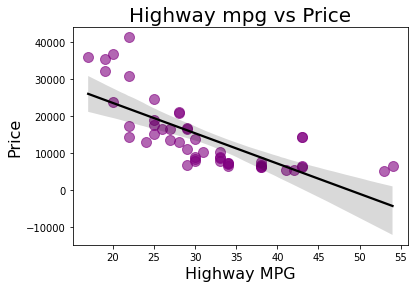

In [ ]:
sns.regplot(x=df['highway-mpg'], y=df['price'], scatter_kws={"color":"purple", "s":100, "alpha":0.6},
            line_kws={"color":"black"})
plt.title("Highway mpg vs Price", fontsize=20)
plt.xlabel("Highway MPG", fontsize=16)
plt.ylabel("Price", fontsize=16)

### ***We can see a down trend with the highway mpg and price***, in the correlation function we saw that -0.7 we shows that as Highway mpg increases price decreases, this is a negative correlation

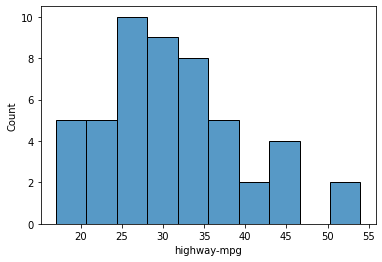

In [ ]:
sns.histplot(df['highway-mpg'], bins=10)

### *we can also see that most cars has a highway-mpg of 25 - 35*

# ***Let us see how fuel type affect the price of car, we can use a box plot for this analysis***
***boxplot works well for data with categories like gender: male and female***

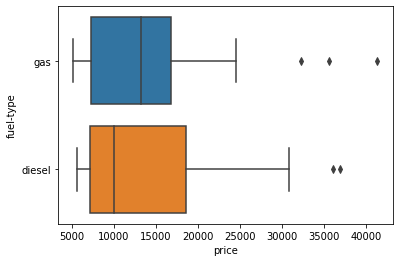

In [ ]:
sns.boxplot(x='price', y='fuel-type', data=df)

### **here data = df is used to refer to the data set loaded into df using pandas**

From the box plot we can see that the average price of cars with fueltype of gas is 14000, while the average price of cars with diesel is 10000, the point outside the wix ( the line ), are known as outliners they can reduce the efficency of a machine learning model

## **Let analyse the relationship between the number of doors and price, using the boxplot in seaborn**

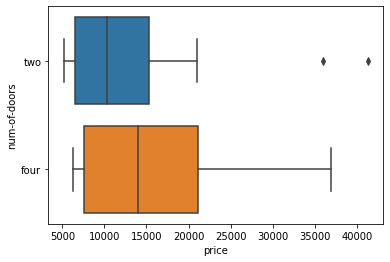

In [ ]:
sns.boxplot(x='price', y='num-of-doors', data=df)

### **From the box plot we can see that the average price of cars when number of doors is two is 10000, while the average price of cars when number of door is four is 14000.**

## **Let us check the relationship between normalized-losses and price**

### *Normalized-losses is the relative average loss payment per insured vehicle year*

Text(0, 0.5, 'Price')

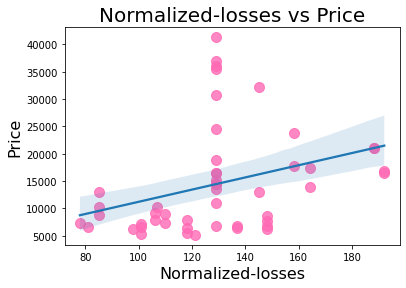

In [ ]:
sns.regplot(x='normalized-losses', y='price', data=df, scatter_kws={"color":"hotpink", "s":100})
plt.title("Normalized-losses vs Price", fontsize=20)
plt.xlabel("Normalized-losses", fontsize=16)
plt.ylabel("Price", fontsize=16)

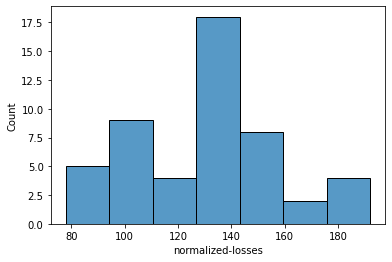

In [ ]:
sns.histplot(x='normalized-losses', data=df)

## We can see that most cars have a normalized loss between 100 - 145

# ***From this analysis we have been able to determine the effect of Horsepower, Engine size, Highway mpg, Fuel type, number of doors and the normalized losses on the Price of cars***